EXPERIMENT 4
MULTI-ARMED BANDIT PROBLEM (Exploration vs Exploitation)

Aim:
To implement the Multi-Armed Bandit using
the Epsilon-Greedy algorithm and compare
Exploration and Exploitation.

Training Completed Successfully.

Estimated Rewards
Arm 1 = 1.65
Arm 2 = 2.88
Arm 3 = 1.85
Arm 4 = 4.21
Arm 5 = 3.37

Best Arm : 4
Estimated Reward : 4.21


Exploration vs Exploitation
Exploration Count : 96
Exploitation Count : 904


   Arm  True Reward  Estimated Reward  Times Selected
0    1          1.5              1.65              24
1    2          2.8              2.88              19
2    3          1.9              1.85              64
3    4          4.2              4.21             843
4    5          3.4              3.37              50


         Method  Count  Percentage
0   Exploration     96         9.6
1  Exploitation    904        90.4


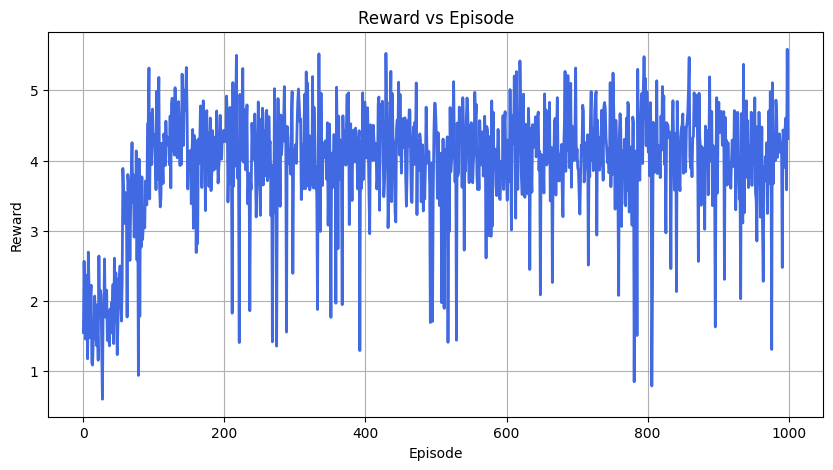

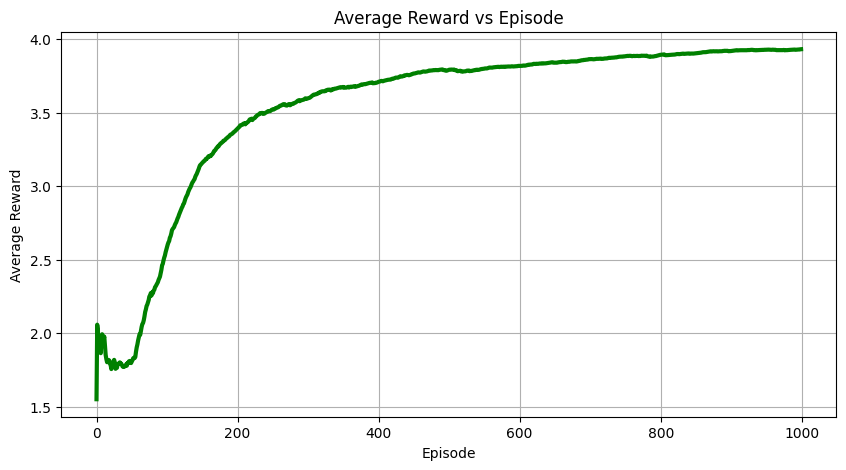

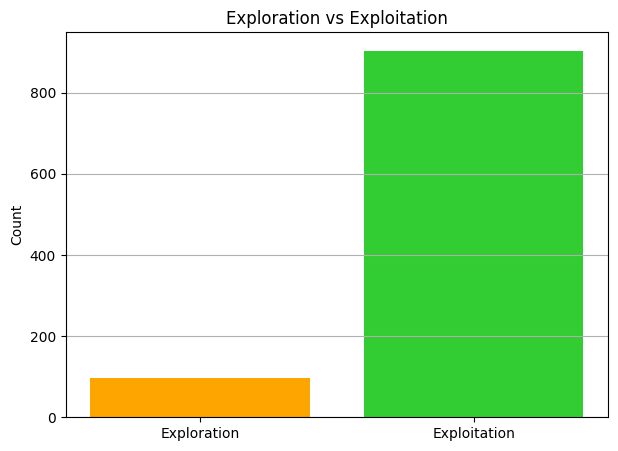

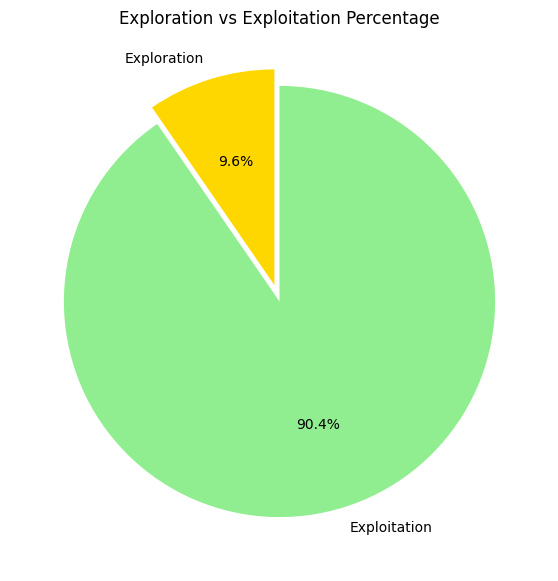

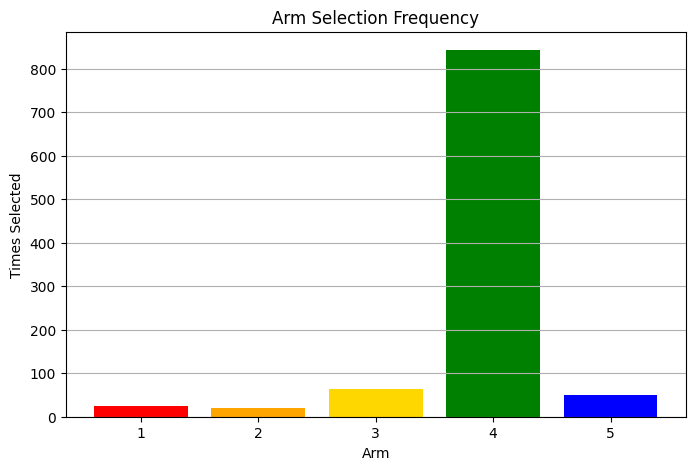

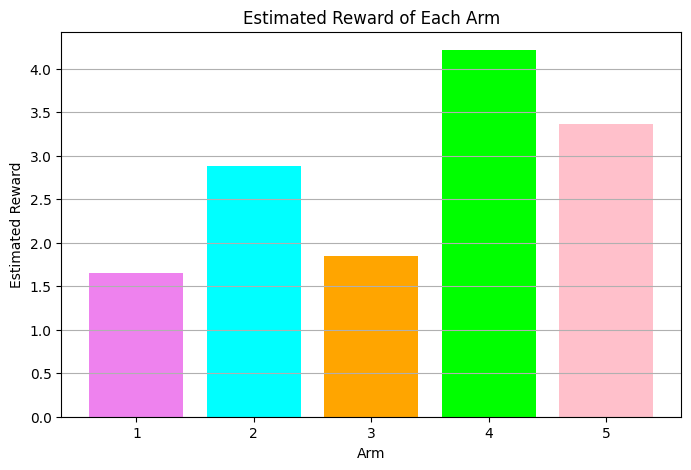

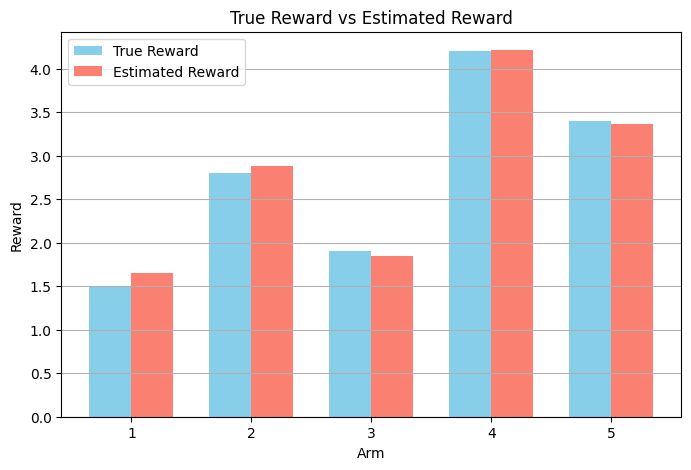

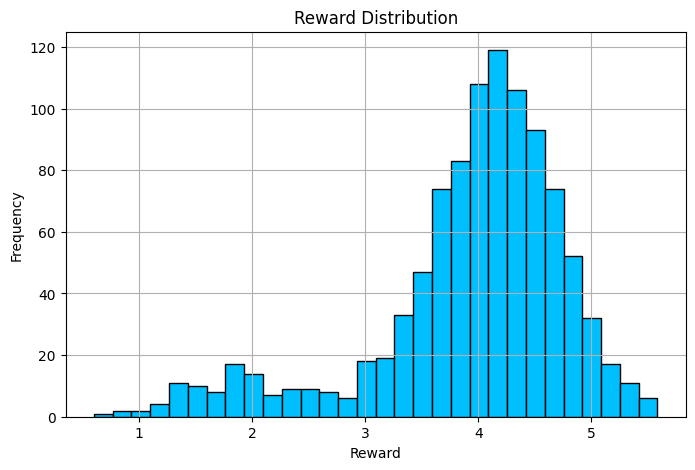

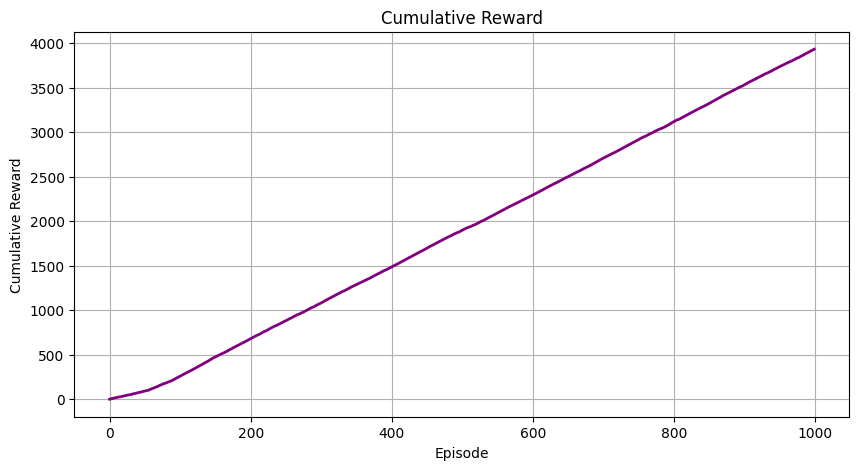



PERFORMANCE METRICS
               Metric    Value
0            Episodes  1000.00
1             Epsilon     0.10
2   Exploration Count    96.00
3  Exploitation Count   904.00
4      Average Reward     3.93
5      Maximum Reward     5.58
6      Minimum Reward     0.60
7            Best Arm     4.00


FINAL SUMMARY TABLE
   Arm  True Reward  Estimated Reward  Times Selected  Selection %
0    1          1.5              1.65              24          2.4
1    2          2.8              2.88              19          1.9
2    3          1.9              1.85              64          6.4
3    4          4.2              4.21             843         84.3
4    5          3.4              3.37              50          5.0


BEST ARM
Best Arm : 4
Estimated Reward : 4.21
Average Reward : 3.93


CONCLUSION
The Multi-Armed Bandit problem was implemented
using the Epsilon-Greedy algorithm.
The agent explored random arms during
exploration and selected the best-known arm
during exploitation.
Over m

In [ ]:
# ==========================================================
# EXPERIMENT 4
# Multi-Armed Bandit (Exploration vs Exploitation)
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

print("="*70)
print("EXPERIMENT 4")
print("MULTI-ARMED BANDIT PROBLEM (Exploration vs Exploitation)")
print("="*70)

# ----------------------------------------------------
# AIM
# ----------------------------------------------------

print("\nAim:")
print("To implement the Multi-Armed Bandit using")
print("the Epsilon-Greedy algorithm and compare")
print("Exploration and Exploitation.")

# ----------------------------------------------------
# PARAMETERS
# ----------------------------------------------------

n_arms = 5

episodes = 1000

epsilon = 0.10

true_rewards = [1.5,2.8,1.9,4.2,3.4]

estimated_rewards = np.zeros(n_arms)

arm_count = np.zeros(n_arms)

reward_history=[]

average_reward=[]

selected_arm=[]

exploration_count=0

exploitation_count=0

# ----------------------------------------------------
# TRAINING
# ----------------------------------------------------

for episode in range(episodes):

    r=random.random()

    # ---------------- Exploration ----------------

    if r<epsilon:

        exploration_count+=1

        arm=random.randint(0,n_arms-1)

    # ---------------- Exploitation ----------------

    else:

        exploitation_count+=1

        arm=np.argmax(estimated_rewards)

    reward=np.random.normal(true_rewards[arm],0.50)

    arm_count[arm]+=1

    estimated_rewards[arm]+=(
        reward-estimated_rewards[arm]
    )/arm_count[arm]

    reward_history.append(reward)

    selected_arm.append(arm+1)

    average_reward.append(np.mean(reward_history))

print("\nTraining Completed Successfully.")

# ----------------------------------------------------
# RESULTS
# ----------------------------------------------------

print("\nEstimated Rewards")

for i in range(n_arms):

    print("Arm",i+1,"=",round(estimated_rewards[i],2))

best_arm=np.argmax(estimated_rewards)+1

print("\nBest Arm :",best_arm)

print("Estimated Reward :",round(max(estimated_rewards),2))

# ----------------------------------------------------
# EXPLORATION vs EXPLOITATION
# ----------------------------------------------------

print("\n")

print("="*60)

print("Exploration vs Exploitation")

print("="*60)

print("Exploration Count :",exploration_count)

print("Exploitation Count :",exploitation_count)

# ----------------------------------------------------
# SUMMARY TABLE
# ----------------------------------------------------

summary=pd.DataFrame({

"Arm":[1,2,3,4,5],

"True Reward":true_rewards,

"Estimated Reward":np.round(estimated_rewards,2),

"Times Selected":arm_count.astype(int)

})

print("\n")

print(summary)

summary.to_csv("Bandit_Summary.csv",index=False)

# ----------------------------------------------------
# EXPLORATION SUMMARY
# ----------------------------------------------------

comparison=pd.DataFrame({

"Method":[

"Exploration",

"Exploitation"

],

"Count":[

exploration_count,

exploitation_count

],

"Percentage":[

round(exploration_count/episodes*100,2),

round(exploitation_count/episodes*100,2)

]

})

print("\n")

print(comparison)

# ==========================================================
# VISUALIZATION 1
# Reward vs Episode
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(reward_history,
         color="royalblue",
         linewidth=2)

plt.title("Reward vs Episode")

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.grid(True)

plt.show()

# ==========================================================
# VISUALIZATION 2
# Average Reward vs Episode
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(average_reward,
         color="green",
         linewidth=3)

plt.title("Average Reward vs Episode")

plt.xlabel("Episode")

plt.ylabel("Average Reward")

plt.grid(True)

plt.show()

# ==========================================================
# VISUALIZATION 3
# Exploration vs Exploitation (Bar Graph)
# ==========================================================

plt.figure(figsize=(7,5))

plt.bar(

["Exploration","Exploitation"],

[exploration_count,exploitation_count],

color=["orange","limegreen"]

)

plt.title("Exploration vs Exploitation")

plt.ylabel("Count")

plt.grid(axis="y")

plt.show()

# ==========================================================
# VISUALIZATION 4
# Exploration vs Exploitation (Pie Chart)
# ==========================================================

plt.figure(figsize=(7,7))

plt.pie(

[exploration_count,exploitation_count],

labels=["Exploration","Exploitation"],

autopct="%1.1f%%",

colors=["gold","lightgreen"],

startangle=90,

explode=[0.08,0]

)

plt.title("Exploration vs Exploitation Percentage")

plt.show()

# ==========================================================
# VISUALIZATION 5
# Arm Selection Frequency
# ==========================================================

plt.figure(figsize=(8,5))

colors=["red","orange","gold","green","blue"]

plt.bar(

range(1,n_arms+1),

arm_count,

color=colors

)

plt.xticks(range(1,n_arms+1))

plt.xlabel("Arm")

plt.ylabel("Times Selected")

plt.title("Arm Selection Frequency")

plt.grid(axis="y")

plt.show()

# ==========================================================
# VISUALIZATION 6
# Estimated Reward of Each Arm
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(

range(1,n_arms+1),

estimated_rewards,

color=["violet","cyan","orange","lime","pink"]

)

plt.xticks(range(1,n_arms+1))

plt.xlabel("Arm")

plt.ylabel("Estimated Reward")

plt.title("Estimated Reward of Each Arm")

plt.grid(axis="y")

plt.show()

# ==========================================================
# VISUALIZATION 7
# True Reward vs Estimated Reward
# ==========================================================

plt.figure(figsize=(8,5))

x=np.arange(n_arms)

width=0.35

plt.bar(

x-width/2,

true_rewards,

width,

label="True Reward",

color="skyblue"

)

plt.bar(

x+width/2,

estimated_rewards,

width,

label="Estimated Reward",

color="salmon"

)

plt.xticks(x,[1,2,3,4,5])

plt.xlabel("Arm")

plt.ylabel("Reward")

plt.title("True Reward vs Estimated Reward")

plt.legend()

plt.grid(axis="y")

plt.show()

# ==========================================================
# VISUALIZATION 8
# Reward Distribution
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(
    reward_history,
    bins=30,
    color="deepskyblue",
    edgecolor="black"
)

plt.title("Reward Distribution")

plt.xlabel("Reward")

plt.ylabel("Frequency")

plt.grid()

plt.show()


# ==========================================================
# VISUALIZATION 9
# Cumulative Reward
# ==========================================================

cumulative_reward=np.cumsum(reward_history)

plt.figure(figsize=(10,5))

plt.plot(
    cumulative_reward,
    color="purple",
    linewidth=2
)

plt.title("Cumulative Reward")

plt.xlabel("Episode")

plt.ylabel("Cumulative Reward")

plt.grid()

plt.show()


# ==========================================================
# PERFORMANCE METRICS
# ==========================================================

performance=pd.DataFrame({

"Metric":[
"Episodes",
"Epsilon",
"Exploration Count",
"Exploitation Count",
"Average Reward",
"Maximum Reward",
"Minimum Reward",
"Best Arm"
],

"Value":[
episodes,
epsilon,
exploration_count,
exploitation_count,
round(np.mean(reward_history),2),
round(np.max(reward_history),2),
round(np.min(reward_history),2),
best_arm
]

})

print("\n")
print("="*70)
print("PERFORMANCE METRICS")
print("="*70)

print(performance)

performance.to_csv("Performance_Metrics.csv",index=False)


# ==========================================================
# FINAL SUMMARY
# ==========================================================

final_summary=pd.DataFrame({

"Arm":[1,2,3,4,5],

"True Reward":np.round(true_rewards,2),

"Estimated Reward":np.round(estimated_rewards,2),

"Times Selected":arm_count.astype(int),

"Selection %":np.round((arm_count/episodes)*100,2)

})

print("\n")
print("="*70)
print("FINAL SUMMARY TABLE")
print("="*70)

print(final_summary)

final_summary.to_csv(
    "Final_Summary.csv",
    index=False
)


# ==========================================================
# BEST ARM
# ==========================================================

print("\n")
print("="*70)
print("BEST ARM")
print("="*70)

print("Best Arm :",best_arm)

print("Estimated Reward :",round(max(estimated_rewards),2))

print("Average Reward :",round(np.mean(reward_history),2))


# ==========================================================
# CONCLUSION
# ==========================================================

print("\n")
print("="*70)
print("CONCLUSION")
print("="*70)

print("The Multi-Armed Bandit problem was implemented")
print("using the Epsilon-Greedy algorithm.")

print("The agent explored random arms during")
print("exploration and selected the best-known arm")
print("during exploitation.")

print("Over multiple episodes, the estimated")
print("rewards converged towards the true rewards.")

print("The experiment demonstrates the trade-off")
print("between exploration and exploitation.")


# ==========================================================
# FILES GENERATED
# ==========================================================

print("\n")
print("="*70)
print("FILES GENERATED")
print("="*70)

print("1. Bandit_Summary.csv")

print("2. Performance_Metrics.csv")

print("3. Final_Summary.csv")

print("\nExperiment 4 Completed Successfully.")